## Finetune eval: generalization trend lines

This notebook loads `results/finetune_eval/**/checkpoint-*/results*.json` outputs and plots **arc_easy accuracy (x-axis)** versus other benchmark accuracies (y-axis) as subplots.

- Each **run** (e.g. `mamba-2.8b-alpaca-lr1e-4`) is drawn as a **line** over checkpoints.
- Metrics use `acc_norm` when available, else `acc`.

If a run has no `results*.json` (e.g. an in-progress eval that only produced `eval.log`), it will be skipped and listed in the summary.

In [2]:
from __future__ import annotations

import os
import json
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _find_repo_root(start: Path | None = None) -> Path | None:
    """Find the *Interplay-LM-Reasoning* repo root.

    Important: Jupyter's working directory can be unrelated to the notebook path.
    So we avoid blindly using CWD if it matches some other repo.

    We look for markers that should be unique to this repo:
    - `analyze/`
    - `results/`
    - `dllm/`
    - `scripts/finetune/`
    """

    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (
            (d / "analyze").is_dir()
            and (d / "results").is_dir()
            and (d / "dllm").is_dir()
            and (d / "scripts" / "finetune").is_dir()
        ):
            return d
    return None


def _pick_existing_dir(candidates: list[Path]) -> Path | None:
    for c in candidates:
        if c is None:
            continue
        c = Path(c).expanduser().resolve()
        if (
            (c / "analyze").is_dir()
            and (c / "results").is_dir()
            and (c / "dllm").is_dir()
            and (c / "scripts" / "finetune").is_dir()
        ):
            return c
    return None


# --- Always chdir into the correct repo root ---
# Override if needed:
#   export INTERPLAY_LM_REASONING_ROOT=/path/to/Interplay-LM-Reasoning
_repo_env = os.environ.get("INTERPLAY_LM_REASONING_ROOT")

REPO_ROOT = _pick_existing_dir(
    [
        Path(_repo_env) if _repo_env else None,
        # Common paths on this cluster
        Path("/fast/pmayilvahanan/Interplay-LM-Reasoning"),
        Path("/lustre/fast/fast/pmayilvahanan/Interplay-LM-Reasoning"),
    ]
) or _find_repo_root()

if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the Interplay-LM-Reasoning repo root. "
        "Set INTERPLAY_LM_REASONING_ROOT or edit REPO_ROOT candidates in this cell."
    )

os.chdir(REPO_ROOT)


def _resolve_results_root() -> Path:
    p = Path("results/finetune_eval")
    if p.exists() and p.is_dir():
        return p
    raise FileNotFoundError(
        f"Could not find finetune eval results at {p.resolve()}. Make sure evaluations have been run."
    )


RESULTS_ROOT = _resolve_results_root()

# Always plot these tasks (x fixed to arc_easy)
X_TASK = "arc_easy"
Y_TASKS = [
    "hellaswag",
    "lambada_openai",
    "mmlu",
    "arc_challenge",
    "piqa",
    "winogrande",
    "openbookqa",
    "commonsense_qa",
]

MODEL_COLORS = {
    "pythia": "#1f77b4",
    "mamba": "#2ca02c",
    "bd3lm": "#ff7f0e",
    "mdlm": "#d62728",
}

MODEL_LINESTYLES = {
    "pythia": "-",
    "mamba": "-",
    "bd3lm": "--",
    "mdlm": "--",
}

# Metric selection:
# - "acc_norm": length-normalized candidate-ranking accuracy when available
# - "acc": unnormalized candidate-ranking accuracy
METRIC = "acc_norm"
FALLBACK_METRIC = True

# Plot only Ultrachat runs.
RUN_NAME_REGEX = r"ultrachat"


def _pick_acc(
    task_metrics: dict,
    metric: str = METRIC,
    fallback: bool = FALLBACK_METRIC,
) -> float | None:
    """Pick accuracy metric from a lm-eval task result dict."""
    if not isinstance(task_metrics, dict):
        return None

    key_map = {"acc": "acc,none", "acc_norm": "acc_norm,none"}
    if metric not in key_map:
        raise ValueError(f"metric must be one of {sorted(key_map)}; got {metric!r}")

    primary = key_map[metric]
    if primary in task_metrics:
        return float(task_metrics[primary])

    if not fallback:
        return None

    secondary = key_map["acc_norm" if metric == "acc" else "acc"]
    if secondary in task_metrics:
        return float(task_metrics[secondary])

    return None


def _load_results_dict(results_path: Path) -> dict:
    data = json.loads(results_path.read_text())
    # lm-eval-harness format
    if isinstance(data, dict) and "results" in data and isinstance(data["results"], dict):
        return data["results"]
    return data


def _find_results_file(ckpt_dir: Path) -> Path | None:
    """Find a lm-eval results file under a checkpoint directory."""
    patterns = [
        "results.json",
        "results_*.json",
        "*/results.json",
        "*/results_*.json",
    ]
    matches: list[Path] = []
    for pat in patterns:
        matches.extend([p for p in ckpt_dir.glob(pat) if p.is_file()])

    if not matches:
        return None

    # Prefer results.json if present; else newest results_*.json
    for p in matches:
        if p.name == "results.json":
            return p
    return max(matches, key=lambda p: p.stat().st_mtime)


_CKPT_RE = re.compile(r"^checkpoint-(\d+)$")


def _parse_step(ckpt_name: str) -> int | None:
    if ckpt_name == "checkpoint-base":
        return -1

    m = _CKPT_RE.match(ckpt_name)
    if m:
        return int(m.group(1))

    return None


def _fill_steps(g: pd.DataFrame) -> pd.DataFrame:
    """Order checkpoints with base first and final last within each run."""
    g = g.copy()
    steps = g["step"].dropna()
    max_step = int(steps.max()) if len(steps) else 0
    g.loc[g["step"].isna(), "step"] = max_step + 1
    g["step"] = g["step"].astype(int)
    return g


@dataclass(frozen=True)
class RunId:
    model_type: str
    run_name: str

    @property
    def label(self) -> str:
        return f"{self.model_type}/{self.run_name}"


def load_finetune_eval(
    results_root: Path = RESULTS_ROOT,
    model_types: Iterable[str] | None = None,
    run_name_regex: str | None = None,
    metric: str = METRIC,
    fallback_metric: bool = FALLBACK_METRIC,
) -> tuple[pd.DataFrame, list[str]]:
    """Load per-checkpoint accuracies from results_root.

    Returns (df, skipped_runs).
    """
    model_types_set = set(model_types) if model_types is not None else None
    run_pat = re.compile(run_name_regex) if run_name_regex else None

    rows: list[dict] = []
    skipped: list[str] = []

    for model_dir in sorted(results_root.iterdir()):
        if not model_dir.is_dir():
            continue
        model_type = model_dir.name
        if model_types_set is not None and model_type not in model_types_set:
            continue

        for run_dir in sorted(model_dir.iterdir()):
            if not run_dir.is_dir():
                continue
            if run_pat is not None and run_pat.search(run_dir.name) is None:
                continue

            run_id = RunId(model_type=model_type, run_name=run_dir.name)
            found_any = False

            for ckpt_dir in sorted(run_dir.iterdir()):
                if not ckpt_dir.is_dir():
                    continue

                results_file = _find_results_file(ckpt_dir)
                if results_file is None:
                    continue

                found_any = True
                results = _load_results_dict(results_file)

                row = {
                    "model_type": model_type,
                    "run_name": run_dir.name,
                    "run_id": run_id.label,
                    "checkpoint": ckpt_dir.name,
                    "step": _parse_step(ckpt_dir.name),
                    "results_path": str(results_file),
                }

                for task in [X_TASK, *Y_TASKS]:
                    row[f"{task}_acc"] = _pick_acc(
                        results.get(task, {}),
                        metric=metric,
                        fallback=fallback_metric,
                    )

                rows.append(row)

            if not found_any:
                skipped.append(run_id.label)

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df, skipped

    df = df.groupby("run_id", group_keys=False).apply(_fill_steps)
    return df, skipped


plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

In [5]:
df, skipped_runs = load_finetune_eval(
    run_name_regex=RUN_NAME_REGEX,
    metric=METRIC,
    fallback_metric=FALLBACK_METRIC,
)

if len(df):
    df = df.sort_values(["model_type", "run_name", "step"])

print("REPO_ROOT:", REPO_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)
print(f"metric: {METRIC} (fallback={FALLBACK_METRIC})")
print(f"run filter: {RUN_NAME_REGEX!r}")
print("loaded rows:", len(df))
print("unique runs:", df["run_id"].nunique() if len(df) else 0)

if skipped_runs:
    print("\nRuns with no results*.json (skipped):")
    for r in skipped_runs:
        print(" -", r)

if len(df):
    display(
        df.groupby(["model_type", "run_name"])  # noqa: F821
        .agg(
            n_checkpoints=("checkpoint", "nunique"),
            checkpoints=("checkpoint", lambda s: tuple(s)),
        )
        .sort_values(["model_type", "run_name"])
    )

    # Quick sanity: show which tasks have missing acc
    cols = [f"{t}_acc" for t in [X_TASK, *Y_TASKS]]
    missing = df[cols].isna().mean().sort_values(ascending=False)
    display(missing.to_frame("fraction_missing"))  # noqa: F821

    # Variance diagnostics (range in percentage points) for arc_easy
    arc = (
        df.groupby("run_id")[f"{X_TASK}_acc"]
        .agg(["count", "min", "max", "std"])
        .sort_values("count", ascending=False)
    )
    arc["range_pp"] = (arc["max"] - arc["min"]) * 100
    display(arc.sort_values("range_pp"))  # noqa: F821

REPO_ROOT: /lustre/fast/fast/pmayilvahanan/Interplay-LM-Reasoning
RESULTS_ROOT: results/finetune_eval
metric: acc_norm (fallback=True)
run filter: 'ultrachat'
loaded rows: 55
unique runs: 5


n_checkpoints  \
model_type run_name                                              
bd3lm      pythia-2.8b-bd3lm-bs1-ultrachat200k              11   
           pythia-2.8b-bd3lm-bs16-ultrachat200k             11   
mamba      mamba-2.8b-ultrachat200k                         11   
mdlm       pythia-2.8b-mdlm-ultrachat200k                   11   
pythia     pythia-2.8b-ultrachat200k                        11   

                                                                                       checkpoints  
model_type run_name                                                                                 
bd3lm      pythia-2.8b-bd3lm-bs1-ultrachat200k   (checkpoint-base, checkpoint-84, checkpoint-12...  
           pythia-2.8b-bd3lm-bs16-ultrachat200k  (checkpoint-base, checkpoint-84, checkpoint-12...  
mamba      mamba-2.8b-ultrachat200k              (checkpoint-base, checkpoint-84, checkpoint-12...  
mdlm       pythia-2.8b-mdlm-ultrachat200k        (checkpoint-base, checkpoint-84, checkpoint-12...  
pythia     pythia-2.8b-ultrachat200k             (checkpoint-base, checkpoint-84, checkpoint-12...

,fraction_missing
hellaswag_acc,1.0
arc_easy_acc,0.0
lambada_openai_acc,0.0
mmlu_acc,0.0
arc_challenge_acc,0.0
piqa_acc,0.0
winogrande_acc,0.0
openbookqa_acc,0.0
commonsense_qa_acc,0.0


,count,min,max,std,range_pp
run_id,,,,,
mamba/mamba-2.8b-ultrachat200k,11,0.600168,0.642256,0.012356,4.208754
pythia/pythia-2.8b-ultrachat200k,11,0.520623,0.588384,0.016814,6.776094
bd3lm/pythia-2.8b-bd3lm-bs1-ultrachat200k,11,0.441919,0.551768,0.027857,10.984848
bd3lm/pythia-2.8b-bd3lm-bs16-ultrachat200k,11,0.268098,0.409933,0.039176,14.183502
mdlm/pythia-2.8b-mdlm-ultrachat200k,11,0.313552,0.473064,0.047280,15.951178


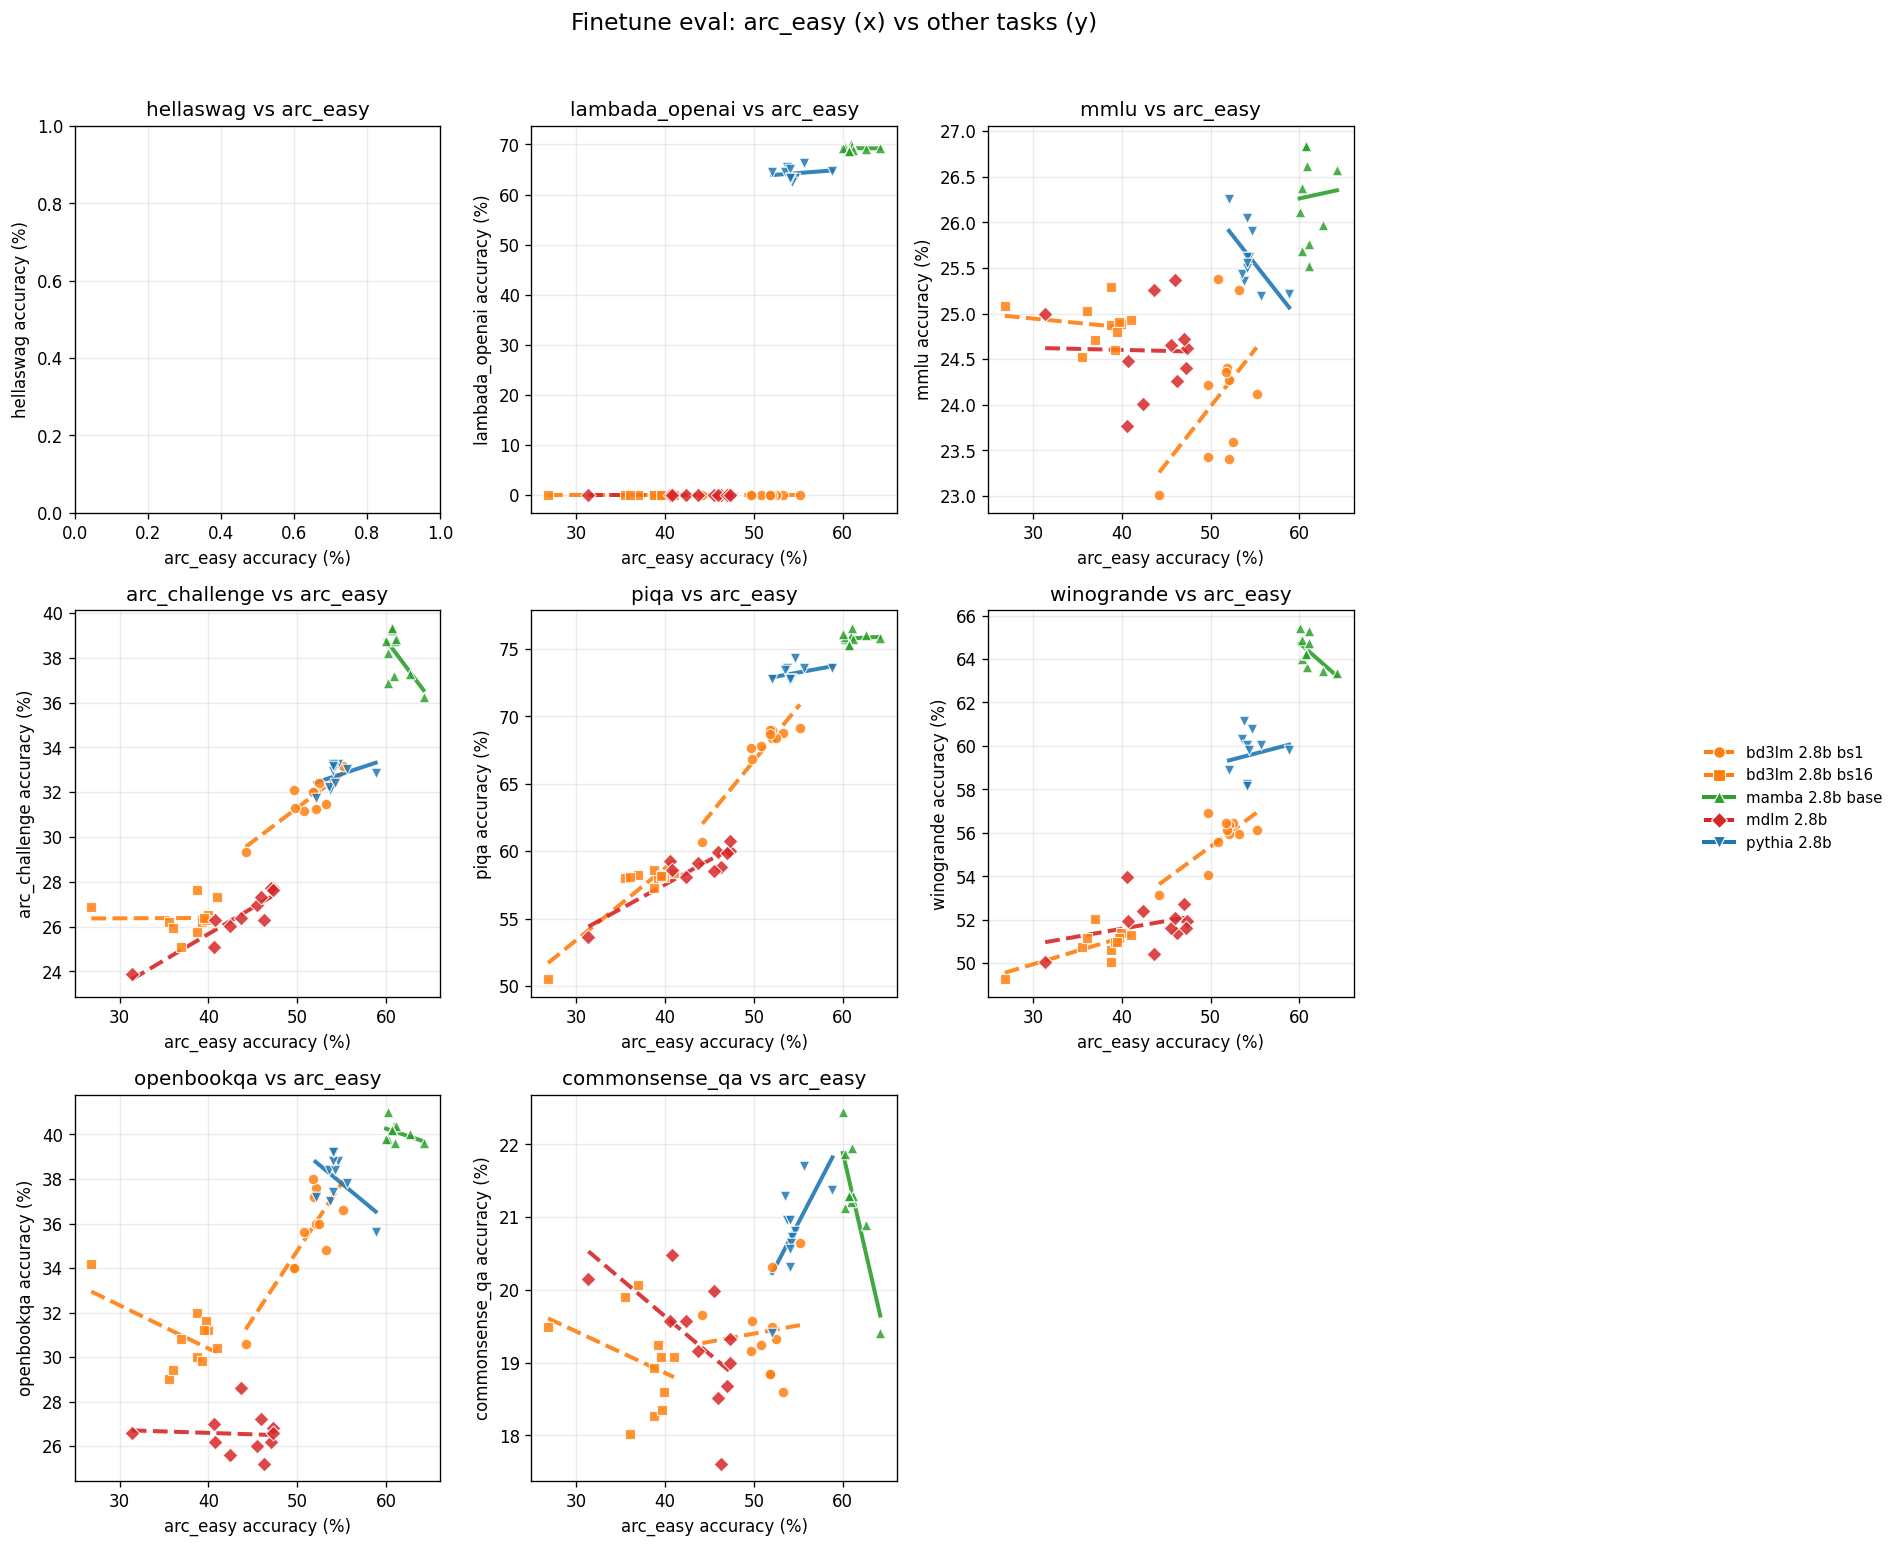

In [6]:
def plot_arc_easy_vs_tasks(
    df: pd.DataFrame,
    x_task: str = X_TASK,
    y_tasks: list[str] = Y_TASKS,
    run_ids: list[str] | None = None,
    legend_max_cols: int = 1,
    min_points_fit: int = 3,
    use_pretty_labels: bool = True,
):
    if len(df) == 0:
        raise ValueError("Empty dataframe: no eval results found.")

    if run_ids is None:
        run_ids = sorted(df["run_id"].unique())

    # Style mapping (marker per run, color per model_type)
    from matplotlib.lines import Line2D

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h"]
    marker_map = {
        rid: marker_cycle[i % len(marker_cycle)] for i, rid in enumerate(run_ids)
    }

    def _pretty_label(rid: str) -> str:
        if not use_pretty_labels:
            return rid
        if "/" not in rid:
            return rid

        model_type, run_name = rid.split("/", 1)
        m_size = re.search(r"([0-9]+(?:[.][0-9]+)?b)", run_name)
        size = m_size.group(1) if m_size else None

        if model_type == "mamba":
            m_lr = re.search(r"lr([0-9.e-]+)", run_name)
            lr = f"lr{m_lr.group(1)}" if m_lr else "base"
            parts = ["mamba", size, lr]
            return " ".join([p for p in parts if p])

        if model_type == "pythia":
            parts = ["pythia", size]
            return " ".join([p for p in parts if p]) or rid

        if model_type == "bd3lm":
            m_bs = re.search(r"bs([0-9]+)", run_name)
            bs = f"bs{m_bs.group(1)}" if m_bs else None
            parts = ["bd3lm", size, bs]
            return " ".join([p for p in parts if p]) or rid

        if model_type == "mdlm":
            parts = ["mdlm", size]
            return " ".join([p for p in parts if p]) or rid

        return rid

    legend_labels = [_pretty_label(rid) for rid in run_ids]
    if len(set(legend_labels)) != len(legend_labels):
        legend_labels = run_ids

    run_to_model = df.groupby("run_id")["model_type"].first().to_dict()
    legend_handles = []
    for rid in run_ids:
        model_type = run_to_model.get(rid, "")
        color = MODEL_COLORS.get(model_type, "gray")
        ls = MODEL_LINESTYLES.get(model_type, "-")
        marker = marker_map[rid]
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=color,
                linestyle=ls,
                linewidth=2.4,
                marker=marker,
                markersize=7,
                markerfacecolor=color,
                markeredgecolor="white",
                markeredgewidth=0.7,
            )
        )

    n = len(y_tasks)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax_idx, task_y in enumerate(y_tasks):
        ax = axes[ax_idx]
        col_x = f"{x_task}_acc"
        col_y = f"{task_y}_acc"

        for run_id in run_ids:
            sub = df[df["run_id"] == run_id].copy()
            sub = sub[sub[col_x].notna() & sub[col_y].notna()].sort_values("step")
            if len(sub) < 2:
                continue

            model_type = sub["model_type"].iloc[0]
            color = MODEL_COLORS.get(model_type, "gray")
            ls = MODEL_LINESTYLES.get(model_type, "-")

            x = sub[col_x].to_numpy() * 100
            y = sub[col_y].to_numpy() * 100

            marker = marker_map[run_id]

            # Show checkpoint points
            ax.scatter(
                x,
                y,
                s=40,
                marker=marker,
                color=color,
                edgecolor="white",
                linewidth=0.7,
                alpha=0.85,
                zorder=3,
            )

            # Fit a clean trend line (like the reference figure): y ~ x
            if len(x) >= 2:
                x_rng = float(np.ptp(x))
                y_rng = float(np.ptp(y))

                if x_rng <= 1e-6 and y_rng <= 1e-6:
                    # Completely flat: nothing to fit (points already shown)
                    pass
                elif x_rng <= 1e-6:
                    # Vertical trend (x constant)
                    ax.plot(
                        [float(x.mean()), float(x.mean())],
                        [float(y.min()), float(y.max())],
                        color=color,
                        linestyle=ls,
                        linewidth=2.4,
                        alpha=0.9,
                        zorder=2,
                    )
                elif y_rng <= 1e-6:
                    # Horizontal trend (y constant)
                    ax.plot(
                        [float(x.min()), float(x.max())],
                        [float(y.mean()), float(y.mean())],
                        color=color,
                        linestyle=ls,
                        linewidth=2.4,
                        alpha=0.9,
                        zorder=2,
                    )
                elif len(x) >= min_points_fit:
                    slope, intercept = np.polyfit(x, y, 1)
                    x_fit = np.linspace(float(x.min()), float(x.max()), 100)
                    y_fit = slope * x_fit + intercept
                    ax.plot(
                        x_fit,
                        y_fit,
                        color=color,
                        linestyle=ls,
                        linewidth=2.4,
                        alpha=0.9,
                        zorder=2,
                    )
                else:
                    # With only 2 points, the fit is just the connecting segment.
                    order = np.argsort(x)
                    ax.plot(
                        x[order],
                        y[order],
                        color=color,
                        linestyle=ls,
                        linewidth=2.4,
                        alpha=0.9,
                        zorder=2,
                    )

        ax.set_title(f"{task_y} vs {x_task}")
        ax.set_xlabel(f"{x_task} accuracy (%)")
        ax.set_ylabel(f"{task_y} accuracy (%)")

    # Hide unused axes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    # One shared legend (one entry per run)
    if legend_handles:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            frameon=False,
            ncol=legend_max_cols,
            fontsize=9,
        )

    fig.suptitle("Finetune eval: arc_easy (x) vs other tasks (y)", y=1.02, fontsize=14)
    # Leave room on the right for the legend
    fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))
    return fig


# Choose which runs to plot (None = all runs with results)
RUN_IDS = None  # e.g. ["mamba/mamba-2.8b-alpaca", "bd3lm/pythia-2.8b-bd3lm-bs32-alpaca"]

fig = plot_arc_easy_vs_tasks(df, run_ids=RUN_IDS)
plt.show()

In [3]:
# =============================================================================
# Part 2: Per-sample log-likelihood analysis (margin & loss-to-loss curves)
#
# After running the reeval scripts with --log_samples, this section loads
# per-instance log-likelihoods and computes:
#   1. margin(x)       = f(correct) - max(f(wrong))
#   2. softmax_margin  = f(correct) - logsumexp(f(all))
#   3. mean_loglik     = average f(correct) across instances
#   4. continuation token counts for comparability annotation
# =============================================================================

import glob
from scipy.special import logsumexp as _logsumexp

SAMPLES_ROOT = Path("results/finetune_eval_samples")

# ── Load per-sample JSONL ───────────────────────────────────────────────────

def _find_sample_files(ckpt_dir: Path) -> dict[str, Path]:
    """Find samples_<task>.jsonl files; return {task_name: path}."""
    out = {}
    patterns = ["samples_*.jsonl", "*/samples_*.jsonl"]
    for pat in patterns:
        for p in ckpt_dir.glob(pat):
            task = p.stem.replace("samples_", "")
            out[task] = p
    return out


def _load_samples(path: Path) -> list[dict]:
    """Load a JSONL samples file."""
    samples = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                samples.append(json.loads(line))
    return samples


def _extract_instance_loglikelihoods(sample: dict) -> dict | None:
    """Extract per-choice log-likelihoods from a single lm-eval sample.

    lm-eval --log_samples format for multiple_choice / loglikelihood tasks:
      - "resps": list of lists, one per choice; inner = [(loglik, is_greedy)]
      - "filtered_resps": same after filtering (often identical)
      - "target": index of correct choice (int or str)
      - "arguments": list of (context, continuation) pairs, one per choice

    Returns dict with keys:
      logliks, target_idx, n_tokens (word-approx), correct_loglik,
      margin, softmax_margin, max_cont_tokens
    """
    resps = sample.get("filtered_resps") or sample.get("resps", [])
    if not resps:
        return None

    logliks = []
    for r in resps:
        if isinstance(r, (list, tuple)):
            inner = r[0] if len(r) > 0 else r
            if isinstance(inner, (list, tuple)):
                logliks.append(float(inner[0]))
            else:
                logliks.append(float(inner))
        else:
            logliks.append(float(r))

    target = sample.get("target", 0)
    if isinstance(target, str):
        target = int(target) if target.isdigit() else 0
    target_idx = int(target)

    # Approximate continuation token count from whitespace-split.
    # Exact tokenizer counts need the tokenizer; word count is a reasonable proxy
    # and sufficient for filtering short (1-3 word) continuations.
    arguments = sample.get("arguments", [])
    n_tokens = []
    for arg in arguments:
        if isinstance(arg, (list, tuple)) and len(arg) >= 2:
            cont_str = str(arg[1]).strip()
            n_tokens.append(max(1, len(cont_str.split())))
        else:
            n_tokens.append(-1)

    if target_idx >= len(logliks):
        return None

    correct_ll = logliks[target_idx]
    wrong_lls = [ll for i, ll in enumerate(logliks) if i != target_idx]
    margin = correct_ll - max(wrong_lls) if wrong_lls else 0.0
    all_lls = np.array(logliks)
    softmax_margin = correct_ll - float(_logsumexp(all_lls))

    return {
        "logliks": logliks,
        "target_idx": target_idx,
        "n_tokens": n_tokens,
        "correct_loglik": correct_ll,
        "margin": margin,
        "softmax_margin": softmax_margin,
        "max_cont_tokens": max(n_tokens) if n_tokens else -1,
    }


def load_sample_metrics(
    samples_root: Path = SAMPLES_ROOT,
    run_name_regex: str | None = r"ultrachat",
    tasks: list[str] | None = None,
    max_cont_tokens: int | None = None,
) -> pd.DataFrame:
    """Load per-checkpoint, per-task aggregated margin / loglik metrics.

    Args:
        max_cont_tokens: if set, only include instances where ALL choices have
            <= this many continuation tokens (for comparability filtering).
    """
    run_pat = re.compile(run_name_regex) if run_name_regex else None
    rows = []

    for model_dir in sorted(samples_root.iterdir()):
        if not model_dir.is_dir():
            continue
        model_type = model_dir.name

        for run_dir in sorted(model_dir.iterdir()):
            if not run_dir.is_dir():
                continue
            if run_pat and not run_pat.search(run_dir.name):
                continue

            for ckpt_dir in sorted(run_dir.iterdir()):
                if not ckpt_dir.is_dir():
                    continue

                step = _parse_step(ckpt_dir.name)
                sample_files = _find_sample_files(ckpt_dir)

                if not sample_files:
                    continue

                row = {
                    "model_type": model_type,
                    "run_name": run_dir.name,
                    "run_id": f"{model_type}/{run_dir.name}",
                    "checkpoint": ckpt_dir.name,
                    "step": step,
                }

                for task_name, sample_path in sample_files.items():
                    if tasks and task_name not in tasks:
                        continue

                    samples = _load_samples(sample_path)
                    margins, softmax_margins, correct_lls = [], [], []
                    n_included, n_total = 0, len(samples)
                    token_counts = []

                    for s in samples:
                        info = _extract_instance_loglikelihoods(s)
                        if info is None:
                            continue

                        token_counts.append(info["max_cont_tokens"])

                        if max_cont_tokens is not None and info["max_cont_tokens"] > max_cont_tokens:
                            continue

                        n_included += 1
                        margins.append(info["margin"])
                        softmax_margins.append(info["softmax_margin"])
                        correct_lls.append(info["correct_loglik"])

                    if n_included > 0:
                        row[f"{task_name}_margin"] = float(np.mean(margins))
                        row[f"{task_name}_softmax_margin"] = float(np.mean(softmax_margins))
                        row[f"{task_name}_mean_loglik"] = float(np.mean(correct_lls))
                        row[f"{task_name}_n_samples"] = n_included
                        row[f"{task_name}_n_total"] = n_total
                    if token_counts:
                        row[f"{task_name}_median_cont_tokens"] = float(np.median(token_counts))

                rows.append(row)

    df = pd.DataFrame(rows)
    if len(df) > 0:
        df = df.groupby("run_id", group_keys=False).apply(_fill_steps)
    return df


print("Sample-loading utilities defined.")
print(f"SAMPLES_ROOT: {SAMPLES_ROOT}")
print(f"  exists: {SAMPLES_ROOT.exists()}")

Sample-loading utilities defined.
SAMPLES_ROOT: results/finetune_eval_samples
  exists: True


In [4]:
# =============================================================================
# Part 2b: Plot loss-to-loss / margin-to-margin curves
# =============================================================================

def plot_metric_vs_metric(
    df: pd.DataFrame,
    x_task: str = X_TASK,
    y_tasks: list[str] = Y_TASKS,
    metric_suffix: str = "margin",
    run_ids: list[str] | None = None,
    title_prefix: str = "Finetune eval",
    ylabel_suffix: str = "",
    min_points_fit: int = 3,
):
    """Generic x-task vs y-task scatter/trend plot for any metric suffix.

    Expects columns like '{task}_{metric_suffix}' in df.
    Works for metric_suffix in: 'margin', 'softmax_margin', 'mean_loglik'.
    """
    if len(df) == 0:
        print("No data to plot.")
        return None

    if run_ids is None:
        run_ids = sorted(df["run_id"].unique())

    from matplotlib.lines import Line2D

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h"]
    marker_map = {rid: marker_cycle[i % len(marker_cycle)] for i, rid in enumerate(run_ids)}

    def _pretty(rid):
        if "/" not in rid:
            return rid
        mt, rn = rid.split("/", 1)
        m_size = re.search(r"([0-9]+(?:[.][0-9]+)?b)", rn)
        sz = m_size.group(1) if m_size else ""
        if mt == "bd3lm":
            m_bs = re.search(r"bs([0-9]+)", rn)
            bs = f"bs{m_bs.group(1)}" if m_bs else ""
            return " ".join(filter(None, [mt, sz, bs]))
        return " ".join(filter(None, [mt, sz]))

    legend_labels = [_pretty(r) for r in run_ids]
    run_to_model = df.groupby("run_id")["model_type"].first().to_dict()

    legend_handles = []
    for rid in run_ids:
        mt = run_to_model.get(rid, "")
        c = MODEL_COLORS.get(mt, "gray")
        ls = MODEL_LINESTYLES.get(mt, "-")
        legend_handles.append(
            Line2D([0], [0], color=c, linestyle=ls, linewidth=2.4,
                   marker=marker_map[rid], markersize=7,
                   markerfacecolor=c, markeredgecolor="white", markeredgewidth=0.7)
        )

    n = len(y_tasks)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    metric_label = metric_suffix.replace("_", " ")
    if not ylabel_suffix:
        ylabel_suffix = metric_label

    for ax_idx, task_y in enumerate(y_tasks):
        ax = axes[ax_idx]
        col_x = f"{x_task}_{metric_suffix}"
        col_y = f"{task_y}_{metric_suffix}"

        if col_x not in df.columns or col_y not in df.columns:
            ax.set_title(f"{task_y}: no data")
            continue

        for run_id in run_ids:
            sub = df[df["run_id"] == run_id].copy()
            sub = sub[sub[col_x].notna() & sub[col_y].notna()].sort_values("step")
            if len(sub) < 2:
                continue

            mt = sub["model_type"].iloc[0]
            color = MODEL_COLORS.get(mt, "gray")
            ls = MODEL_LINESTYLES.get(mt, "-")
            x = sub[col_x].to_numpy()
            y = sub[col_y].to_numpy()

            ax.scatter(x, y, s=40, marker=marker_map[run_id], color=color,
                       edgecolor="white", linewidth=0.7, alpha=0.85, zorder=3)

            if len(x) >= 2:
                x_rng, y_rng = float(np.ptp(x)), float(np.ptp(y))
                if x_rng > 1e-6 and y_rng > 1e-6 and len(x) >= min_points_fit:
                    slope, intercept = np.polyfit(x, y, 1)
                    x_fit = np.linspace(x.min(), x.max(), 100)
                    ax.plot(x_fit, slope * x_fit + intercept, color=color,
                            linestyle=ls, linewidth=2.4, alpha=0.9, zorder=2)
                elif x_rng > 1e-6 or y_rng > 1e-6:
                    order = np.argsort(x)
                    ax.plot(x[order], y[order], color=color, linestyle=ls,
                            linewidth=2.4, alpha=0.9, zorder=2)

        ax.set_title(f"{task_y} vs {x_task}")
        ax.set_xlabel(f"{x_task} {ylabel_suffix}")
        ax.set_ylabel(f"{task_y} {ylabel_suffix}")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    if legend_handles:
        fig.legend(legend_handles, legend_labels, loc="center left",
                   bbox_to_anchor=(1.01, 0.5), frameon=False, ncol=1, fontsize=9)

    fig.suptitle(f"{title_prefix}: {x_task} (x) vs other tasks (y) — {metric_label}",
                 y=1.02, fontsize=14)
    fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))
    return fig


# ── Load and plot (all instances) ───────────────────────────────────────────
if SAMPLES_ROOT.exists():
    df_samples = load_sample_metrics(max_cont_tokens=None)
    print(f"Loaded {len(df_samples)} checkpoint rows from per-sample results")
    if len(df_samples) > 0:
        print(f"Runs: {sorted(df_samples['run_id'].unique())}")
        print()

        fig_margin = plot_metric_vs_metric(
            df_samples, metric_suffix="margin",
            title_prefix="Finetune eval (all instances)",
            ylabel_suffix="margin (correct − best wrong)",
        )
        plt.show()

        fig_loglik = plot_metric_vs_metric(
            df_samples, metric_suffix="mean_loglik",
            title_prefix="Finetune eval (all instances)",
            ylabel_suffix="mean log-lik (correct)",
        )
        plt.show()

        # ── Short-continuation subset (max 3 tokens per choice) ────────
        df_short = load_sample_metrics(max_cont_tokens=3)
        if len(df_short) > 0:
            fig_short = plot_metric_vs_metric(
                df_short, metric_suffix="margin",
                title_prefix="Finetune eval (≤3 tok continuations)",
                ylabel_suffix="margin",
            )
            plt.show()
else:
    print(
        f"No per-sample results yet at {SAMPLES_ROOT}.\n"
        "Run the reeval scripts first:\n"
        "  bash scripts/finetune/reeval_ultrachat_ar.sh\n"
        "  bash scripts/finetune/reeval_ultrachat_diffusion.sh"
    )

NameError: name '_fill_steps' is not defined

In [ ]:
# =============================================================================
# Part 2c: Token-count diagnostics — how many instances are "comparable"?
#
# For each task, show the distribution of max continuation tokens across
# all choices, so you can see which tasks / what fraction of instances have
# short (single-token or near-single-token) continuations where the MC-ELBO
# is essentially equivalent to exact AR log-likelihood.
# =============================================================================

def token_count_report(
    samples_root: Path = SAMPLES_ROOT,
    tasks: list[str] | None = None,
    thresholds: list[int] = [1, 2, 3, 5, 10],
):
    """Print and return token-count stats per task from ONE checkpoint's samples."""
    if not samples_root.exists():
        print(f"No samples at {samples_root}")
        return None

    # Pick one checkpoint to inspect (any model, first available)
    sample_files = {}
    for p in sorted(samples_root.rglob("samples_*.jsonl")):
        task = p.stem.replace("samples_", "")
        if task not in sample_files:
            sample_files[task] = p

    if tasks:
        sample_files = {k: v for k, v in sample_files.items() if k in tasks}

    rows = []
    for task, path in sorted(sample_files.items()):
        samples = _load_samples(path)
        max_tokens_per_instance = []
        all_cont_tokens = []

        for s in samples:
            info = _extract_instance_loglikelihoods(s)
            if info is None:
                continue
            max_tokens_per_instance.append(info["max_cont_tokens"])
            all_cont_tokens.extend(info["n_tokens"])

        if not max_tokens_per_instance:
            continue

        arr = np.array(max_tokens_per_instance)
        row = {
            "task": task,
            "n_instances": len(arr),
            "median_max_tok": float(np.median(arr)),
            "mean_max_tok": float(np.mean(arr)),
            "p90_max_tok": float(np.percentile(arr, 90)),
        }
        for t in thresholds:
            row[f"frac_≤{t}_tok"] = float(np.mean(arr <= t))

        rows.append(row)

    df_tc = pd.DataFrame(rows)
    if len(df_tc) > 0:
        print("=== Continuation token counts (max across choices per instance) ===")
        print(df_tc.to_string(index=False, float_format="%.2f"))
        print()

        # Histogram
        n_tasks = len(df_tc)
        fig, axes = plt.subplots(1, min(n_tasks, 4), figsize=(4 * min(n_tasks, 4), 3))
        if n_tasks == 1:
            axes = [axes]
        axes = list(axes)

        for i, (_, r) in enumerate(df_tc.iterrows()):
            if i >= len(axes):
                break
            task = r["task"]
            sf = sample_files[task]
            samples = _load_samples(sf)
            max_toks = []
            for s in samples:
                info = _extract_instance_loglikelihoods(s)
                if info:
                    max_toks.append(info["max_cont_tokens"])

            axes[i].hist(max_toks, bins=range(0, max(max_toks) + 2), edgecolor="white")
            axes[i].set_title(task)
            axes[i].set_xlabel("max cont. tokens")
            axes[i].set_ylabel("count")
            for t in [1, 3]:
                axes[i].axvline(t + 0.5, color="red", linestyle="--", alpha=0.5)

        fig.suptitle("Continuation token counts per instance (one checkpoint)", fontsize=12)
        fig.tight_layout()
        plt.show()

    return df_tc


if SAMPLES_ROOT.exists():
    df_tokens = token_count_report(tasks=[X_TASK] + Y_TASKS)
else:
    print("Run reeval scripts first to generate per-sample data.")